In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/CottonShield_AI/dataset"

print(os.listdir(dataset_path))

['cotton-leaf-disease-dataset.zip']


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/CottonShield_AI/dataset/cotton-leaf-disease-dataset.zip"

extract_path = "/content/cotton_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
import os

print(os.listdir(extract_path))

['cotton']


In [5]:
dataset_folder = "/content/cotton_dataset/cotton"

print(os.listdir(dataset_folder))

['bacterial_blight', 'curl_virus', 'fussarium_wilt', 'healthy']


# 1. Exploratory Data Analysis (EDA)

Before training deep learning models, we first analyze the dataset to understand its distribution, class balance, image characteristics, and potential preprocessing requirements.

In [6]:
import os

dataset_folder = "/content/cotton_dataset/cotton"

classes = sorted(os.listdir(dataset_folder))

image_count = {}

total = 0

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_folder, cls)))
    image_count[cls] = count
    total += count

print("Total Images :", total)

print()

for k,v in image_count.items():
    print(f"{k:20s} {v}")

Total Images : 1711

bacterial_blight     448
curl_virus           418
fussarium_wilt       419
healthy              426


In [7]:
import pandas as pd

df = pd.DataFrame({
    "Disease": image_count.keys(),
    "Images": image_count.values()
})

df

,Disease,Images
0,bacterial_blight,448
1,curl_virus,418
2,fussarium_wilt,419
3,healthy,426


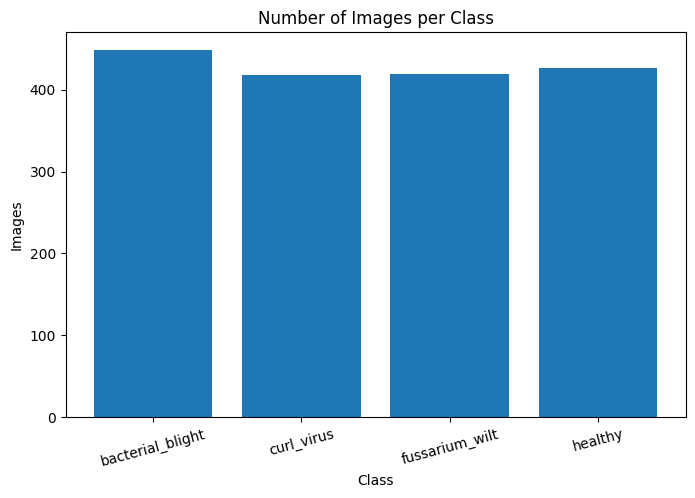

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Disease"], df["Images"])

plt.title("Number of Images per Class")

plt.xlabel("Class")

plt.ylabel("Images")

plt.xticks(rotation=15)

plt.show()

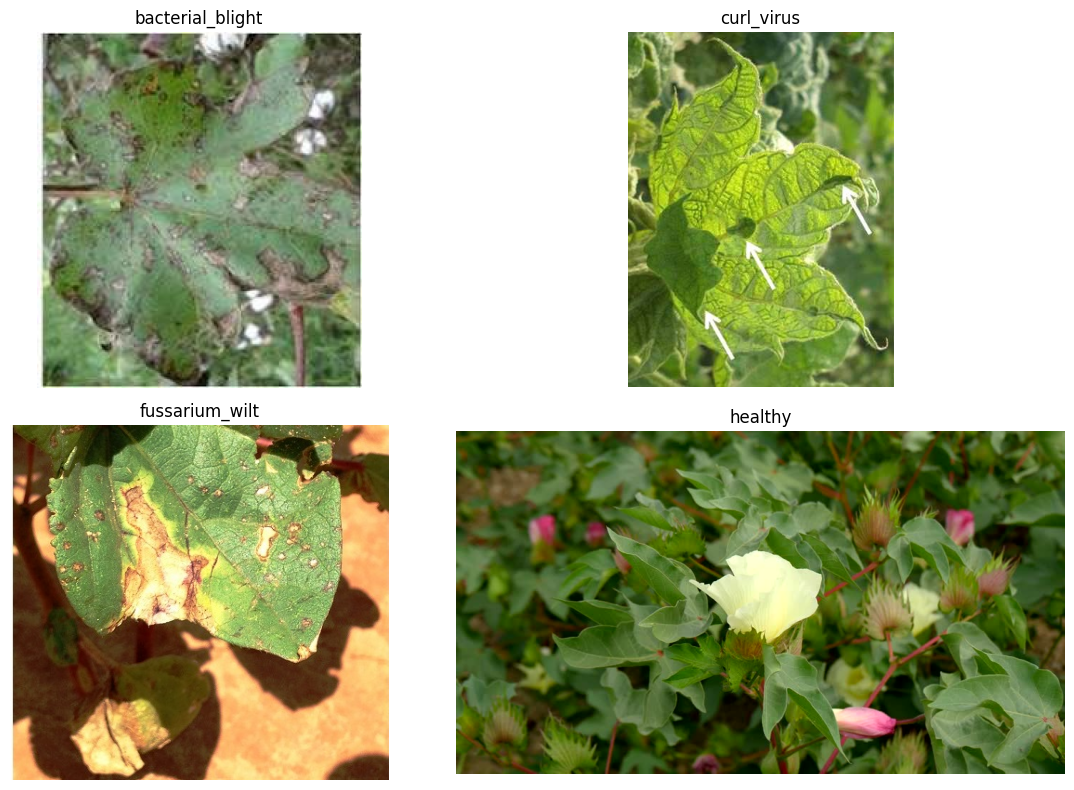

In [9]:
import random
from PIL import Image

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_folder, cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [10]:
sizes = []

for cls in classes:

    folder = os.path.join(dataset_folder, cls)

    for file in os.listdir(folder):

        img = Image.open(os.path.join(folder,file))

        sizes.append(img.size)

sizes[:10]

[(400, 600),
 (540, 720),
 (768, 619),
 (165, 220),
 (326, 416),
 (571, 428),
 (300, 225),
 (768, 510),
 (250, 380),
 (720, 540)]

In [11]:
widths = [s[0] for s in sizes]

heights = [s[1] for s in sizes]

print("Average Width :", sum(widths)/len(widths))

print("Average Height:", sum(heights)/len(heights))

Average Width : 449.7118644067797
Average Height: 436.10870835768554


In [12]:
from PIL import Image

bad = 0

for cls in classes:

    folder = os.path.join(dataset_folder, cls)

    for file in os.listdir(folder):

        try:

            Image.open(os.path.join(folder,file)).verify()

        except:

            bad += 1

print("Corrupted Images :", bad)

Corrupted Images : 0


In [13]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [15]:
dataset = datasets.ImageFolder(
    dataset_folder,
    transform=train_transform
)

print(dataset.classes)

['bacterial_blight', 'curl_virus', 'fussarium_wilt', 'healthy']


In [16]:
import torch

print(torch.__version__)

2.11.0+cu128


In [17]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [18]:
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [19]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 1197
Validation Images : 256
Testing Images : 257


In [21]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [22]:
from torchvision import models
import torch.nn as nn

In [23]:
def get_model(model_name, num_classes):

    if model_name == "mobilenet_v3":
        model = models.mobilenet_v3_large(weights="DEFAULT")
        model.classifier[3] = nn.Linear(
            model.classifier[3].in_features,
            num_classes
        )

    elif model_name == "resnet50":
        model = models.resnet50(weights="DEFAULT")
        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    elif model_name == "densenet121":
        model = models.densenet121(weights="DEFAULT")
        model.classifier = nn.Linear(
            model.classifier.in_features,
            num_classes
        )

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights="DEFAULT")
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights="DEFAULT")
        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features,
            num_classes
        )

    elif model_name == "vgg16":

        model = models.vgg16(weights="DEFAULT")

        model.classifier[6] = nn.Linear(
        model.classifier[6].in_features,
        num_classes
        )
    else:
        raise ValueError("Model not supported")

    return model

In [24]:
model = get_model("resnet50",4)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [29]:
# ==========================
# Hyperparameters
# ==========================

NUM_CLASSES = 4
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [27]:
criterion = nn.CrossEntropyLoss()

In [30]:
def get_optimizer(model):
    return torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

In [31]:
def get_scheduler(optimizer):
    return torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=5,
        gamma=0.1
    )

In [32]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [35]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [34]:
def train_model(model_name):

    print("="*60)
    print(f"Training {model_name}")
    print("="*60)

    model = get_model(model_name, NUM_CLASSES)

    model = model.to(DEVICE)

    optimizer = get_optimizer(model)

    scheduler = get_scheduler(optimizer)

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return model

In [53]:
model = train_model("resnet50")

Training resnet50
Epoch 1/10 | Train Acc: 90.06% | Val Acc: 71.48%
Epoch 2/10 | Train Acc: 93.65% | Val Acc: 96.48%
Epoch 3/10 | Train Acc: 95.41% | Val Acc: 94.14%
Epoch 4/10 | Train Acc: 96.83% | Val Acc: 94.92%
Epoch 5/10 | Train Acc: 97.41% | Val Acc: 92.58%
Epoch 6/10 | Train Acc: 98.16% | Val Acc: 97.66%
Epoch 7/10 | Train Acc: 99.58% | Val Acc: 99.22%
Epoch 8/10 | Train Acc: 99.50% | Val Acc: 100.00%
Epoch 9/10 | Train Acc: 99.92% | Val Acc: 99.22%
Epoch 10/10 | Train Acc: 99.67% | Val Acc: 99.61%


In [40]:
print(train_dataset.indices[:10])
print(val_dataset.indices[:10])
print(test_dataset.indices[:10])

[1212, 307, 314, 1051, 1578, 1170, 202, 963, 538, 1010]
[562, 1600, 965, 1394, 1020, 750, 193, 432, 222, 355]
[874, 721, 1334, 1669, 1361, 1346, 1623, 194, 239, 443]


In [41]:
train_set = set(train_dataset.indices)
val_set = set(val_dataset.indices)
test_set = set(test_dataset.indices)

print("Train-Val overlap:", len(train_set & val_set))
print("Train-Test overlap:", len(train_set & test_set))
print("Val-Test overlap:", len(val_set & test_set))


Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [37]:
def evaluate_model(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    cm = confusion_matrix(y_true, y_pred)

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    return accuracy, precision, recall, f1, cm

In [38]:
accuracy, precision, recall, f1, cm = evaluate_model(
    model,
    test_loader
)

AttributeError: 'str' object has no attribute 'eval'

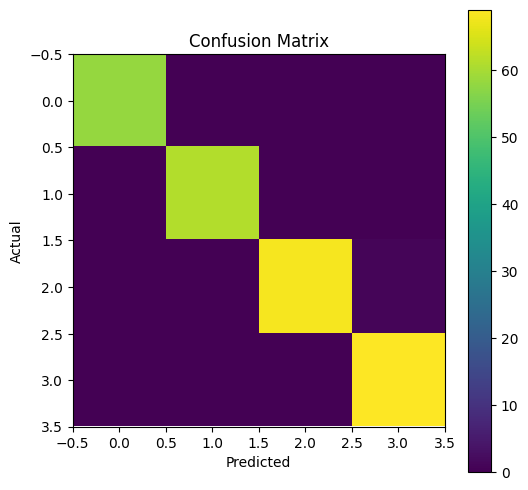

In [59]:
plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [60]:
from sklearn.metrics import classification_report

class_names = dataset.classes

predictions = []
ground_truth = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        predictions.extend(preds.cpu().numpy())

        ground_truth.extend(labels.numpy())

print(
    classification_report(
        ground_truth,
        predictions,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

bacterial_blight       1.00      1.00      1.00        58
      curl_virus       1.00      1.00      1.00        61
  fussarium_wilt       1.00      0.99      0.99        69
         healthy       0.99      1.00      0.99        69

        accuracy                           1.00       257
       macro avg       1.00      1.00      1.00       257
    weighted avg       1.00      1.00      1.00       257



In [61]:
torch.save(
    model.state_dict(),
    "resnet50_cotton.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [62]:
print(train_dataset.indices[:10])
print(val_dataset.indices[:10])
print(test_dataset.indices[:10])

[1212, 307, 314, 1051, 1578, 1170, 202, 963, 538, 1010]
[562, 1600, 965, 1394, 1020, 750, 193, 432, 222, 355]
[874, 721, 1334, 1669, 1361, 1346, 1623, 194, 239, 443]


In [63]:
train_set = set(train_dataset.indices)
val_set = set(val_dataset.indices)
test_set = set(test_dataset.indices)

print("Train-Val overlap :", len(train_set & val_set))
print("Train-Test overlap:", len(train_set & test_set))
print("Val-Test overlap  :", len(val_set & test_set))

Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0


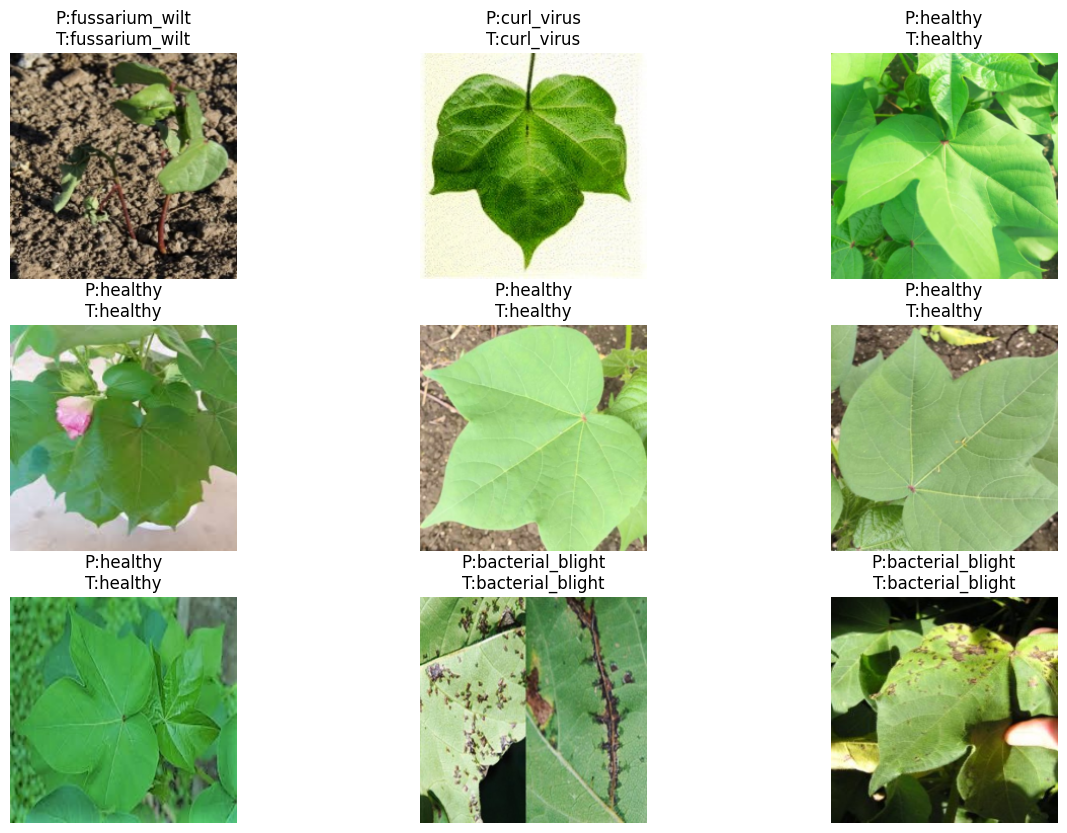

In [64]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

images = images.to(DEVICE)

outputs = model(images)

_, preds = torch.max(outputs,1)

images = images.cpu()

fig = plt.figure(figsize=(15,10))

for i in range(9):

    ax = fig.add_subplot(3,3,i+1)

    img = images[i].permute(1,2,0)

    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])

    img = img.clamp(0,1)

    ax.imshow(img)

    ax.set_title(
        f"P:{dataset.classes[preds[i]]}\nT:{dataset.classes[labels[i]]}"
    )

    ax.axis("off")

plt.show()

In [25]:
# ============================================================
# Create Project Folders
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/CottonShield_AI"

MODELS_DIR = os.path.join(PROJECT_DIR, "Models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "Figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [26]:
# ============================================================
# Initialize Results File
# ============================================================

RESULTS_FILE = os.path.join(RESULTS_DIR, "model_comparison.csv")

results_df = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Training Time (Seconds)"
])

results_df.to_csv(RESULTS_FILE, index=False)

print("Results file created at:")
print(RESULTS_FILE)

Results file created at:
/content/drive/MyDrive/CottonShield_AI/Results/model_comparison.csv


In [27]:
# ============================================================
# Models to Compare
# ============================================================

MODELS = [
    "mobilenet_v3",
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "vgg16"
]

print("Models to be trained:")
for model in MODELS:
    print("-", model)

Models to be trained:
- mobilenet_v3
- resnet50
- densenet121
- efficientnet_b0
- vgg16


In [44]:
criterion = nn.CrossEntropyLoss()

In [45]:
print(criterion)

CrossEntropyLoss()


In [46]:
print("DEVICE:", DEVICE)
print("NUM_CLASSES:", NUM_CLASSES)
print("LEARNING_RATE:", LEARNING_RATE)
print("EPOCHS:", EPOCHS)
print("criterion:", criterion)

DEVICE: cuda
NUM_CLASSES: 4
LEARNING_RATE: 0.001
EPOCHS: 8
criterion: CrossEntropyLoss()


In [47]:
# ============================================================
# Train, Evaluate and Save All Models
# ============================================================

import time
import pandas as pd

for model_name in MODELS:

    print("\n" + "=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    # -------------------------
    # Train Model
    # -------------------------
    start_time = time.time()

    model = train_model(model_name)

    training_time = round(time.time() - start_time, 2)

    # -------------------------
    # Evaluate Model
    # -------------------------
    accuracy, precision, recall, f1, cm = evaluate_model(
        model,
        test_loader
    )

    # -------------------------
    # Save Model
    # -------------------------
    model_path = os.path.join(
        MODELS_DIR,
        f"{model_name}.pth"
    )

    torch.save(model.state_dict(), model_path)

    print(f"{model_name} saved to:")
    print(model_path)

    # -------------------------
    # Save Confusion Matrix
    # -------------------------
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    figure_path = os.path.join(
        FIGURES_DIR,
        f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.close()

    # -------------------------
    # Update Results CSV
    # -------------------------
    new_row = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4),
        "Training Time (Seconds)": training_time
    }])

    existing = pd.read_csv(RESULTS_FILE)
    existing = pd.concat([existing, new_row], ignore_index=True)
    existing.to_csv(RESULTS_FILE, index=False)

    print("\nCurrent Results")
    print(existing)

print("\n" + "="*70)
print("All experiments completed successfully!")
print("="*70)


Training mobilenet_v3
Training mobilenet_v3
Epoch 1/8 | Train Acc: 91.81% | Val Acc: 94.53%
Epoch 2/8 | Train Acc: 96.83% | Val Acc: 91.41%
Epoch 3/8 | Train Acc: 98.58% | Val Acc: 87.89%
Epoch 4/8 | Train Acc: 98.25% | Val Acc: 79.30%
Epoch 5/8 | Train Acc: 96.99% | Val Acc: 93.75%
Epoch 6/8 | Train Acc: 99.25% | Val Acc: 100.00%
Epoch 7/8 | Train Acc: 99.75% | Val Acc: 100.00%
Epoch 8/8 | Train Acc: 99.92% | Val Acc: 100.00%

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
mobilenet_v3 saved to:
/content/drive/MyDrive/CottonShield_AI/Models/mobilenet_v3.pth


/tmp/ipykernel_735/3958019262.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  existing = pd.concat([existing, new_row], ignore_index=True)



Current Results
          Model  Accuracy  Precision  Recall  F1 Score  \
0  mobilenet_v3       1.0        1.0     1.0       1.0   

   Training Time (Seconds)  
0                   103.53  

Training resnet50
Training resnet50
Epoch 1/8 | Train Acc: 89.72% | Val Acc: 66.02%
Epoch 2/8 | Train Acc: 93.73% | Val Acc: 91.41%
Epoch 3/8 | Train Acc: 97.08% | Val Acc: 92.19%
Epoch 4/8 | Train Acc: 96.91% | Val Acc: 99.61%
Epoch 5/8 | Train Acc: 97.49% | Val Acc: 99.22%
Epoch 6/8 | Train Acc: 98.91% | Val Acc: 100.00%
Epoch 7/8 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch 8/8 | Train Acc: 99.92% | Val Acc: 100.00%

Accuracy : 0.9961089494163424
Precision: 0.9961645358532519
Recall   : 0.9961089494163424
F1 Score : 0.9961068672797557
resnet50 saved to:
/content/drive/MyDrive/CottonShield_AI/Models/resnet50.pth

Current Results
          Model  Accuracy  Precision  Recall  F1 Score  \
0  mobilenet_v3    1.0000     1.0000  1.0000    1.0000   
1      resnet50    0.9961     0.9962  0.9961    0.9

100%|██████████| 30.8M/30.8M [00:00<00:00, 138MB/s]


Epoch 1/8 | Train Acc: 87.89% | Val Acc: 81.25%
Epoch 2/8 | Train Acc: 93.57% | Val Acc: 96.48%
Epoch 3/8 | Train Acc: 96.74% | Val Acc: 96.48%
Epoch 4/8 | Train Acc: 98.08% | Val Acc: 98.83%
Epoch 5/8 | Train Acc: 97.83% | Val Acc: 91.02%
Epoch 6/8 | Train Acc: 98.58% | Val Acc: 97.66%
Epoch 7/8 | Train Acc: 99.75% | Val Acc: 99.61%
Epoch 8/8 | Train Acc: 99.75% | Val Acc: 99.61%

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
densenet121 saved to:
/content/drive/MyDrive/CottonShield_AI/Models/densenet121.pth

Current Results
          Model  Accuracy  Precision  Recall  F1 Score  \
0  mobilenet_v3    1.0000     1.0000  1.0000    1.0000   
1      resnet50    0.9961     0.9962  0.9961    0.9961   
2   densenet121    1.0000     1.0000  1.0000    1.0000   

   Training Time (Seconds)  
0                   103.53  
1                   178.03  
2                   174.06  

Training efficientnet_b0
Training efficientnet_b0
Downloading: "https://download.pytorch.org/models/effi

100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]


Epoch 1/8 | Train Acc: 89.89% | Val Acc: 98.05%
Epoch 2/8 | Train Acc: 95.49% | Val Acc: 99.22%
Epoch 3/8 | Train Acc: 97.91% | Val Acc: 98.05%
Epoch 4/8 | Train Acc: 97.91% | Val Acc: 96.88%
Epoch 5/8 | Train Acc: 98.33% | Val Acc: 99.61%
Epoch 6/8 | Train Acc: 98.50% | Val Acc: 99.61%
Epoch 7/8 | Train Acc: 99.67% | Val Acc: 99.61%
Epoch 8/8 | Train Acc: 99.67% | Val Acc: 99.61%

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
efficientnet_b0 saved to:
/content/drive/MyDrive/CottonShield_AI/Models/efficientnet_b0.pth

Current Results
             Model  Accuracy  Precision  Recall  F1 Score  \
0     mobilenet_v3    1.0000     1.0000  1.0000    1.0000   
1         resnet50    0.9961     0.9962  0.9961    0.9961   
2      densenet121    1.0000     1.0000  1.0000    1.0000   
3  efficientnet_b0    1.0000     1.0000  1.0000    1.0000   

   Training Time (Seconds)  
0                   103.53  
1                   178.03  
2                   174.06  
3                   119.

100%|██████████| 528M/528M [00:07<00:00, 78.5MB/s]


Epoch 1/8 | Train Acc: 32.66% | Val Acc: 57.03%
Epoch 2/8 | Train Acc: 59.40% | Val Acc: 46.48%
Epoch 3/8 | Train Acc: 66.83% | Val Acc: 66.41%
Epoch 4/8 | Train Acc: 67.75% | Val Acc: 70.31%
Epoch 5/8 | Train Acc: 80.45% | Val Acc: 71.48%
Epoch 6/8 | Train Acc: 87.55% | Val Acc: 88.67%
Epoch 7/8 | Train Acc: 91.65% | Val Acc: 91.02%
Epoch 8/8 | Train Acc: 93.48% | Val Acc: 94.14%

Accuracy : 0.9066147859922179
Precision: 0.9063823881066817
Recall   : 0.9066147859922179
F1 Score : 0.905140440924722
vgg16 saved to:
/content/drive/MyDrive/CottonShield_AI/Models/vgg16.pth

Current Results
             Model  Accuracy  Precision  Recall  F1 Score  \
0     mobilenet_v3    1.0000     1.0000  1.0000    1.0000   
1         resnet50    0.9961     0.9962  0.9961    0.9961   
2      densenet121    1.0000     1.0000  1.0000    1.0000   
3  efficientnet_b0    1.0000     1.0000  1.0000    1.0000   
4            vgg16    0.9066     0.9064  0.9066    0.9051   

   Training Time (Seconds)  
0          

In [48]:
import os

print(os.listdir(MODELS_DIR))
print(os.listdir(RESULTS_DIR))
print(os.listdir(FIGURES_DIR))

['mobilenet_v3.pth', 'resnet50.pth', 'densenet121.pth', 'efficientnet_b0.pth', 'vgg16.pth']
['model_comparison.csv']
['mobilenet_v3_confusion_matrix.png', 'resnet50_confusion_matrix.png', 'densenet121_confusion_matrix.png', 'efficientnet_b0_confusion_matrix.png', 'vgg16_confusion_matrix.png']


In [49]:
# ============================================================
# Load Training Results
# ============================================================

results_df = pd.read_csv(RESULTS_FILE)

print(results_df)

results_df

             Model  Accuracy  Precision  Recall  F1 Score  \
0     mobilenet_v3    1.0000     1.0000  1.0000    1.0000   
1         resnet50    0.9961     0.9962  0.9961    0.9961   
2      densenet121    1.0000     1.0000  1.0000    1.0000   
3  efficientnet_b0    1.0000     1.0000  1.0000    1.0000   
4            vgg16    0.9066     0.9064  0.9066    0.9051   

   Training Time (Seconds)  
0                   103.53  
1                   178.03  
2                   174.06  
3                   119.19  
4                   234.84  


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds)
0,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53
1,resnet50,0.9961,0.9962,0.9961,0.9961,178.03
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19
4,vgg16,0.9066,0.9064,0.9066,0.9051,234.84


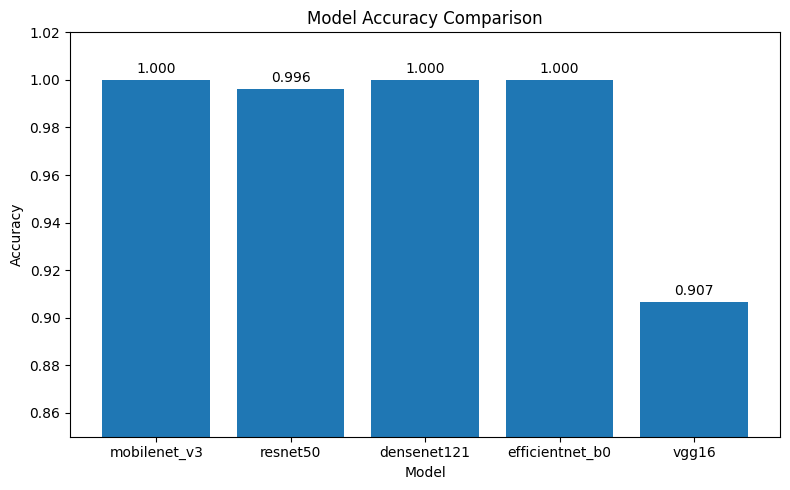

In [50]:
# ============================================================
# Accuracy Comparison
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.ylim(0.85,1.02)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value+0.003, f"{value:.3f}", ha="center")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "accuracy_comparison.png"
    ),
    dpi=300
)

plt.show()

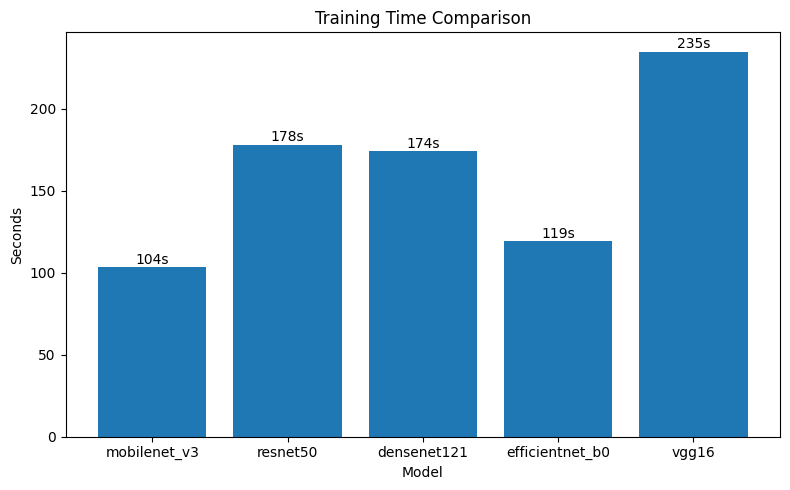

In [51]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Training Time (Seconds)"])

plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.xlabel("Model")

for i, value in enumerate(results_df["Training Time (Seconds)"]):
    plt.text(i, value+2, f"{value:.0f}s", ha="center")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "training_time.png"
    ),
    dpi=300
)

plt.show()

In [53]:
import numpy as np


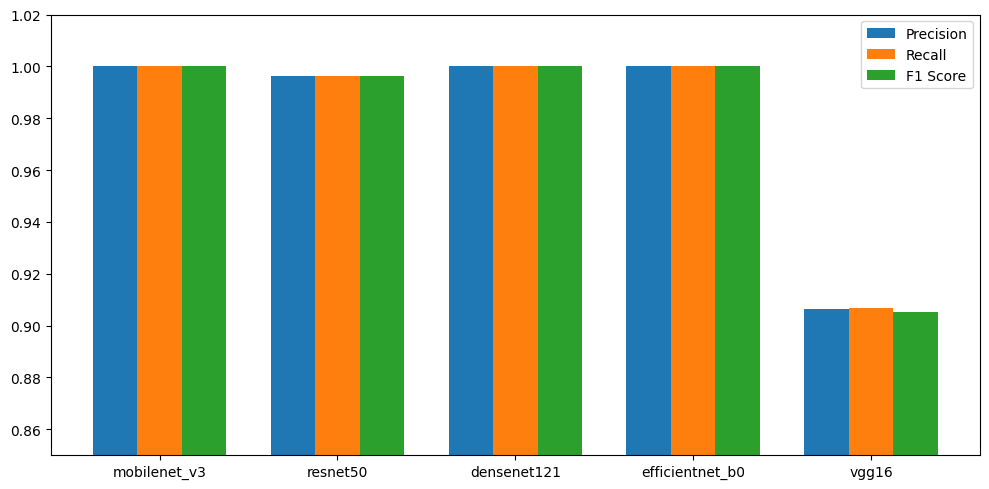

In [54]:
metrics = ["Precision","Recall","F1 Score"]

x = np.arange(len(results_df))

width = 0.25

plt.figure(figsize=(10,5))

plt.bar(
    x-width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x+width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(x, results_df["Model"])

plt.ylim(0.85,1.02)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "metrics_comparison.png"
    ),
    dpi=300
)

plt.show()

In [55]:
# ============================================================
# Calculate Model Size
# ============================================================

model_sizes = []

for model_name in MODELS:

    model_path = os.path.join(
        MODELS_DIR,
        f"{model_name}.pth"
    )

    size_mb = os.path.getsize(model_path) / (1024 * 1024)

    model_sizes.append(round(size_mb,2))

results_df["Model Size (MB)"] = model_sizes

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds),Model Size (MB)
0,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53,16.25
1,resnet50,0.9961,0.9962,0.9961,0.9961,178.03,90.01
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06,27.12
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19,15.59
4,vgg16,0.9066,0.9064,0.9066,0.9051,234.84,512.24


In [56]:
# ============================================================
# Calculate Number of Parameters
# ============================================================

parameter_counts = []

for model_name in MODELS:

    model = get_model(model_name, NUM_CLASSES)

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    parameter_counts.append(
        round(total_params/1e6,2)
    )

results_df["Parameters (Millions)"] = parameter_counts

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds),Model Size (MB),Parameters (Millions)
0,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53,16.25,4.21
1,resnet50,0.9961,0.9962,0.9961,0.9961,178.03,90.01,23.52
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06,27.12,6.96
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19,15.59,4.01
4,vgg16,0.9066,0.9064,0.9066,0.9051,234.84,512.24,134.28


In [57]:
# ============================================================
# Calculate Inference Time
# ============================================================

import time

inference_times = []

sample_image = next(iter(test_loader))[0][0].unsqueeze(0).to(DEVICE)

for model_name in MODELS:

    model = get_model(model_name, NUM_CLASSES)

    model.load_state_dict(
        torch.load(
            os.path.join(
                MODELS_DIR,
                f"{model_name}.pth"
            ),
            map_location=DEVICE
        )
    )

    model = model.to(DEVICE)

    model.eval()

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_image)

    start = time.time()

    with torch.no_grad():
        for _ in range(100):
            _ = model(sample_image)

    end = time.time()

    avg_time = ((end-start)/100)*1000

    inference_times.append(round(avg_time,2))

results_df["Inference Time (ms)"] = inference_times

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds),Model Size (MB),Parameters (Millions),Inference Time (ms)
0,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53,16.25,4.21,12.86
1,resnet50,0.9961,0.9962,0.9961,0.9961,178.03,90.01,23.52,8.31
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06,27.12,6.96,19.38
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19,15.59,4.01,9.66
4,vgg16,0.9066,0.9064,0.9066,0.9051,234.84,512.24,134.28,9.43


In [58]:
# ============================================================
# Save Final Comparison Table
# ============================================================

results_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "final_model_comparison.csv"
    ),
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds),Model Size (MB),Parameters (Millions),Inference Time (ms)
0,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53,16.25,4.21,12.86
1,resnet50,0.9961,0.9962,0.9961,0.9961,178.03,90.01,23.52,8.31
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06,27.12,6.96,19.38
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19,15.59,4.01,9.66
4,vgg16,0.9066,0.9064,0.9066,0.9051,234.84,512.24,134.28,9.43


In [59]:
# ============================================================
# Rank Models by Accuracy
# ============================================================

ranking = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

ranking.index = ranking.index + 1

print("Model Ranking")
display(ranking)

Model Ranking


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (Seconds),Model Size (MB),Parameters (Millions),Inference Time (ms)
1,mobilenet_v3,1.0000,1.0000,1.0000,1.0000,103.53,16.25,4.21,12.86
2,densenet121,1.0000,1.0000,1.0000,1.0000,174.06,27.12,6.96,19.38
3,efficientnet_b0,1.0000,1.0000,1.0000,1.0000,119.19,15.59,4.01,9.66
4,resnet50,0.9961,0.9962,0.9961,0.9961,178.03,90.01,23.52,8.31
5,vgg16,0.9066,0.9064,0.9066,0.9051,234.84,512.24,134.28,9.43


In [60]:
# ============================================================
# Best Model Summary
# ============================================================

best_model = ranking.iloc[0]

print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)

print(f"Model                : {best_model['Model']}")
print(f"Accuracy             : {best_model['Accuracy']:.4f}")
print(f"Precision            : {best_model['Precision']:.4f}")
print(f"Recall               : {best_model['Recall']:.4f}")
print(f"F1 Score             : {best_model['F1 Score']:.4f}")
print(f"Training Time (sec)  : {best_model['Training Time (Seconds)']:.2f}")
print(f"Model Size (MB)      : {best_model['Model Size (MB)']:.2f}")
print(f"Parameters (Million) : {best_model['Parameters (Millions)']:.2f}")
print(f"Inference Time (ms)  : {best_model['Inference Time (ms)']:.2f}")

BEST PERFORMING MODEL
Model                : mobilenet_v3
Accuracy             : 1.0000
Precision            : 1.0000
Recall               : 1.0000
F1 Score             : 1.0000
Training Time (sec)  : 103.53
Model Size (MB)      : 16.25
Parameters (Million) : 4.21
Inference Time (ms)  : 12.86


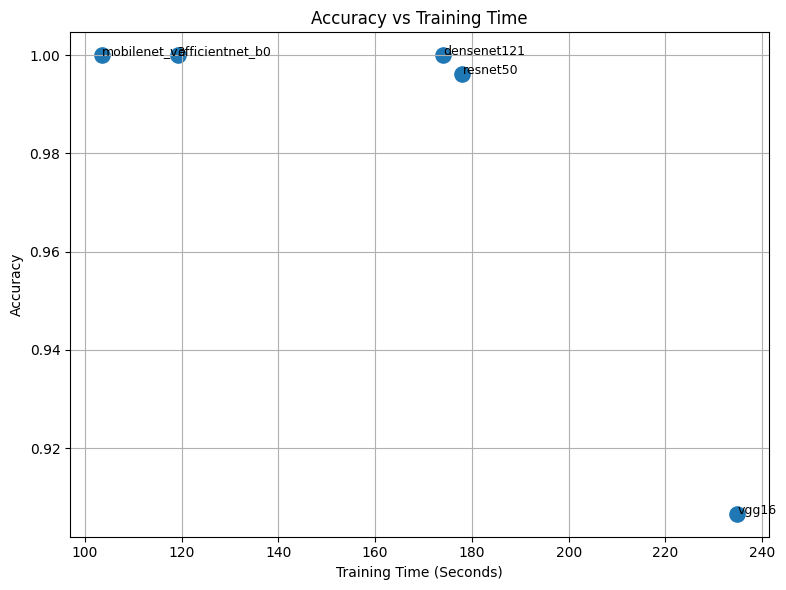

In [61]:
# ============================================================
# Accuracy vs Training Time
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    results_df["Training Time (Seconds)"],
    results_df["Accuracy"],
    s=120
)

for i in range(len(results_df)):
    plt.text(
        results_df["Training Time (Seconds)"][i],
        results_df["Accuracy"][i],
        results_df["Model"][i],
        fontsize=9
    )

plt.xlabel("Training Time (Seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "accuracy_vs_training_time.png"
    ),
    dpi=300
)

plt.show()

In [62]:
results_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "Final_Model_Comparison.csv"
    ),
    index=False
)

ranking.to_csv(
    os.path.join(
        RESULTS_DIR,
        "Model_Ranking.csv"
    ),
    index=False
)

print("All result files saved successfully!")

All result files saved successfully!


In [63]:
# ============================================================
# Predict Disease from a Single Image
# ============================================================

from PIL import Image

class_names = dataset.classes

best_model_name = "mobilenet_v3"

model = get_model(best_model_name, NUM_CLASSES)

model.load_state_dict(
    torch.load(
        os.path.join(
            MODELS_DIR,
            f"{best_model_name}.pth"
        ),
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

model.eval()

print("Model Loaded Successfully!")

Model Loaded Successfully!
